# **TOPIC:** Hansen Tree Cover Share — Ethnologue polygons

## **Author:** JM
### **Notes**: Follows the `Maps_Replication_Presentation_CulturesinCrisis.ipynb` pattern (geopandas + matplotlib, quantile bins, truncated BuPu colormap, custom legend) to render a choropleth of `sh_treecover` for the Ethnologue polygons.

`sh_treecover = treecover_km2 * 100 / area_km2`, capped at 100 (matches `create_folklore_envmeasures.do`).

In [53]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import mapclassify
from matplotlib.patches import Patch
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## - Setting paths and importing shapes

In [54]:
# Set base project path
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")

# Set file paths
poscol_path  = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"
basemap_path = base_path / "maps" / "interim" / "World" / "world_dissolve_nolakes.shp"

hansen_csv = base_path / "maps" / "raw" / "Hansen_forest"  / "ethnologue_treecoverloss_fixed.csv"
bii_csv    = base_path / "maps" / "raw" / "BII"            / "ethnologue_bii.csv"
water_csv  = base_path / "maps" / "raw" / "Water_surface"  / "perm_loss_water.csv"

export_path = Path("C:/Users/juami/Dropbox/Overleaf/Nathan-Maps/plots")
export_path.mkdir(parents=True, exist_ok=True)

In [55]:
# Read the shapefiles
poscol_shape  = gpd.read_file(poscol_path)
basemap_shape = gpd.read_file(basemap_path)

print(poscol_shape.crs)
print(basemap_shape.crs)

EPSG:4326
EPSG:4326


### Fixing Pos-Columbian shape

In [56]:
# Load Hansen treecover + BII + surface-water and compute sh_treecover + sh_seasonwater_base
hansen_df = pd.read_csv(hansen_csv)                               # ID, treecover_km2, treeloss_km2
bii_df    = pd.read_csv(bii_csv)[["ID", "area_km2", "bii"]]
water_df  = pd.read_csv(water_csv)[["ID", "changewater", "seasonalwater_2000_km2"]]

tc_df = (
    hansen_df
    .merge(bii_df,   on="ID", how="left")
    .merge(water_df, on="ID", how="left")
)
tc_df["sh_treecover"]       = tc_df["treecover_km2"] * 100.0 / tc_df["area_km2"]
tc_df["sh_seasonwater_base"] = tc_df["seasonalwater_2000_km2"] * 100.0 / tc_df["area_km2"]

# Cap at 100 (Stata: replace sh_treecover=100 if sh_treecover>100 & sh_treecover!=.)
tc_df.loc[tc_df["sh_treecover"]        > 100, "sh_treecover"]        = 100
tc_df.loc[tc_df["sh_seasonwater_base"] > 100, "sh_seasonwater_base"] = 100

poscol_shape = poscol_shape.merge(
    tc_df[["ID", "sh_treecover", "bii", "changewater", "sh_seasonwater_base"]],
    on="ID", how="left",
)
poscol_shape[["ID", "sh_treecover", "bii", "changewater", "sh_seasonwater_base"]].head()


,ID,sh_treecover,bii,changewater,sh_seasonwater_base
0,RUS-RUS,55.429147,62.477592,-0.326560,0.005543
1,ENG-USA,36.529298,46.022142,0.318669,0.001441
2,POR-BRA,56.114823,61.930540,0.234857,0.001828
3,ENG-AUS,9.021130,46.894566,0.281524,0.006761
4,CMN-CHN,20.465522,45.431188,0.699520,0.004609


## - Replicating the map

In [57]:
# Setting the color palette for the map
def truncate_colormap(cmap_name='Greens', minval=0.3, maxval=1.0, n=100):
    cmap = plt.get_cmap(cmap_name)
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'{cmap_name}_trunc', cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# Stronger Greens (skip the lightest 30%) — thematically fits tree cover
strong_greens = truncate_colormap('Greens', 0.3, 1.0)

### -- Map: Hansen Tree Cover Share

In [58]:
# Define the number of quantiles
num_quantiles = 5

# Create quantile bins and get the labels
poscol_shape['quantile_cat'], bins = pd.qcut(
    poscol_shape['sh_treecover'], q=num_quantiles,
    retbins=True, labels=False, duplicates='drop'
)

# Creating the labels for the legend
label_map = {
    i: f"{bins[i]:.1f} - {bins[i+1]:.1f}"
    for i in range(len(bins) - 1)
}

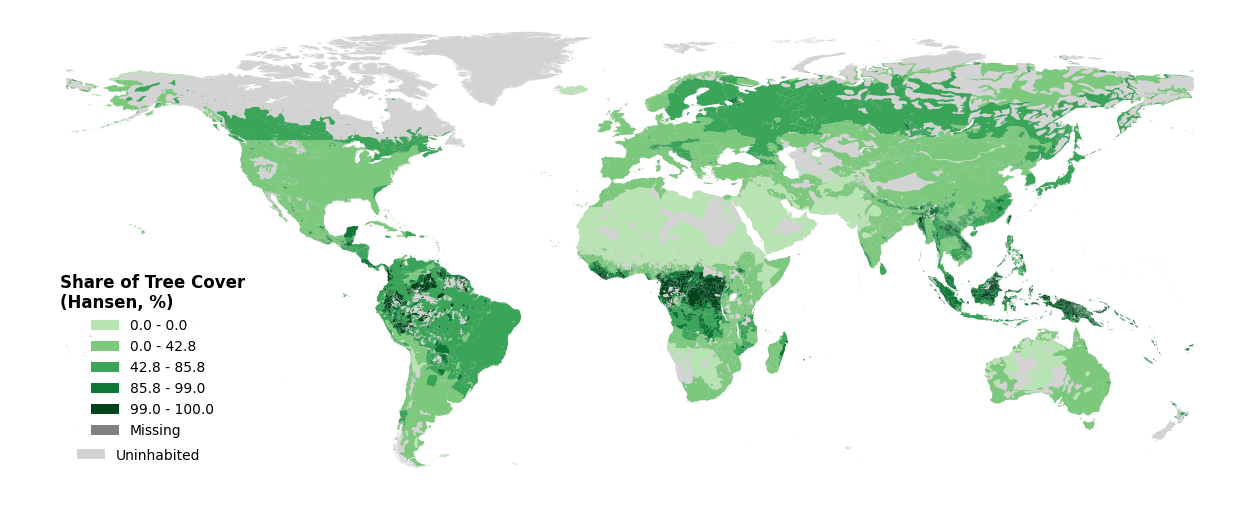

In [59]:
# Step 1: Extract unique categories (excluding NaNs)
categories = poscol_shape['quantile_cat'].dropna().unique()
categories = sorted(categories)

# Step 2: Sample colors from the custom colormap
n = len(categories)
category_colors = strong_greens(np.linspace(0, 1, n))
category_color_map = dict(zip(categories, category_colors))

# Step 3: Map the colors to a new column
poscol_shape['color'] = poscol_shape['quantile_cat'].map(category_color_map)

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor='white')

# Background
basemap_shape.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0
)

# Plot polygons with mapped colors
poscol_shape.plot(
    ax=ax,
    color=poscol_shape['color'].fillna('gray'),
    edgecolor='none',
    linewidth=0
)

# Custom legend
legend_elements = [
    Patch(facecolor=category_color_map[c], label=label_map.get(c, str(c)))
    for c in categories
]
legend_elements.append(Patch(facecolor='gray', label="Missing"))

# Show legend on the map
legend = ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.03, 0.1, 0.2, 0.2),
    frameon=False,
    title="Share of Tree Cover\n(Hansen, %)",
    title_fontproperties=FontProperties(weight='bold', size=12),
    prop=FontProperties(size=10)
)

# Uninhabited patch
uninhabited_patch = Patch(
    facecolor='lightgray',
    edgecolor='none',
    label='Uninhabited'
)
custom_legend = ax.legend(
    handles=[uninhabited_patch],
    loc='lower left',
    bbox_to_anchor=(0.044, 0.05, 0.2, 0.2),
    frameon=False,
    prop=FontProperties(size=10),
)
ax.add_artist(legend)

# Force same spatial extent
ax.set_aspect('equal', adjustable='box')
ax.set_axis_off()

# Save to PDF
plt.savefig(export_path / "Hansen_ShTreecover_POSCOL.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()

### -- Map: Biodiversity Intactness Index (BII)

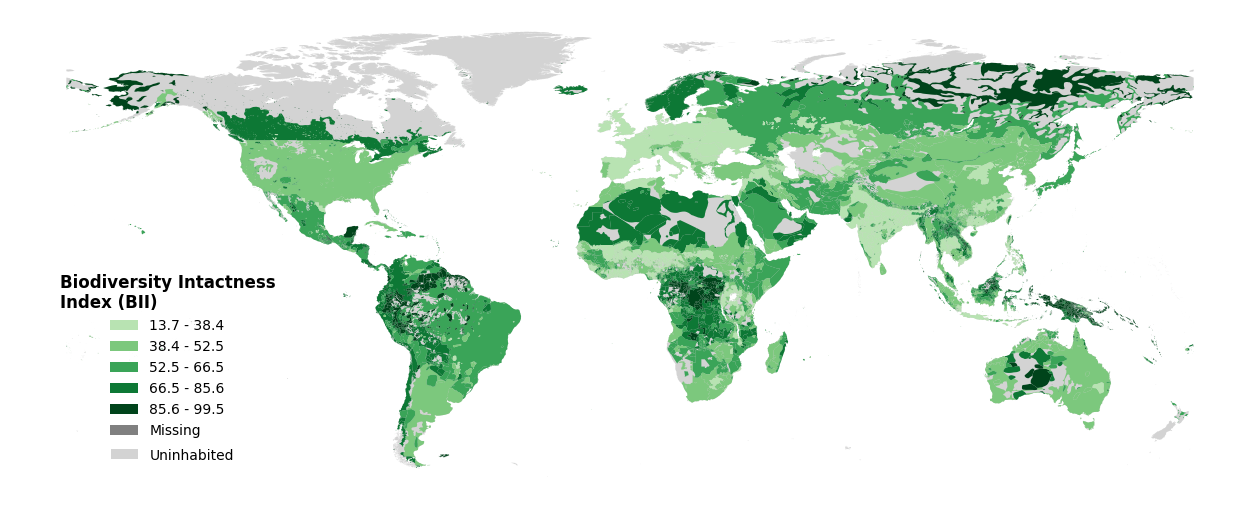

In [60]:
# Define the number of quantiles
num_quantiles = 5

# Create quantile bins and get the labels
poscol_shape['quantile_cat'], bins = pd.qcut(
    poscol_shape['bii'], q=num_quantiles,
    retbins=True, labels=False, duplicates='drop'
)

label_map = {
    i: f"{bins[i]:.1f} - {bins[i+1]:.1f}"
    for i in range(len(bins) - 1)
}

# Step 1: Extract unique categories (excluding NaNs)
categories = poscol_shape['quantile_cat'].dropna().unique()
categories = sorted(categories)

# Step 2: Sample colors from the custom colormap
n = len(categories)
category_colors = strong_greens(np.linspace(0, 1, n))
category_color_map = dict(zip(categories, category_colors))

# Step 3: Map the colors to a new column
poscol_shape['color'] = poscol_shape['quantile_cat'].map(category_color_map)

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor='white')

basemap_shape.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0)
poscol_shape.plot(
    ax=ax,
    color=poscol_shape['color'].fillna('gray'),
    edgecolor='none', linewidth=0
)

legend_elements = [
    Patch(facecolor=category_color_map[c], label=label_map.get(c, str(c)))
    for c in categories
]
legend_elements.append(Patch(facecolor='gray', label="Missing"))

legend = ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.03, 0.1, 0.2, 0.2),
    frameon=False,
    title="Biodiversity Intactness\nIndex (BII)",
    title_fontproperties=FontProperties(weight='bold', size=12),
    prop=FontProperties(size=10)
)

uninhabited_patch = Patch(facecolor='lightgray', edgecolor='none', label='Uninhabited')
custom_legend = ax.legend(
    handles=[uninhabited_patch],
    loc='lower left',
    bbox_to_anchor=(0.071, 0.05, 0.2, 0.2),
    frameon=False,
    prop=FontProperties(size=10),
)
ax.add_artist(legend)

ax.set_aspect('equal', adjustable='box')
ax.set_axis_off()

plt.savefig(export_path / "BII_POSCOL.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

### -- Map: Surface Water Change

In [61]:
# # Define the number of quantiles
# num_quantiles = 5

# # Create quantile bins and get the labels
# poscol_shape['quantile_cat'], bins = pd.qcut(
#     poscol_shape['changewater'], q=num_quantiles,
#     retbins=True, labels=False, duplicates='drop'
# )

# label_map = {
#     i: f"{bins[i]:.2f} - {bins[i+1]:.2f}"
#     for i in range(len(bins) - 1)
# }

# # Step 1: Extract unique categories (excluding NaNs)
# categories = poscol_shape['quantile_cat'].dropna().unique()
# categories = sorted(categories)

# # Step 2: Sample colors from the custom colormap
# n = len(categories)
# category_colors = strong_greens(np.linspace(0, 1, n))
# category_color_map = dict(zip(categories, category_colors))

# # Step 3: Map the colors to a new column
# poscol_shape['color'] = poscol_shape['quantile_cat'].map(category_color_map)

# # Step 4: Plot
# fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor='white')

# basemap_shape.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0)
# poscol_shape.plot(
#     ax=ax,
#     color=poscol_shape['color'].fillna('gray'),
#     edgecolor='none', linewidth=0
# )

# legend_elements = [
#     Patch(facecolor=category_color_map[c], label=label_map.get(c, str(c)))
#     for c in categories
# ]
# legend_elements.append(Patch(facecolor='gray', label="Missing"))

# legend = ax.legend(
#     handles=legend_elements,
#     loc='lower left',
#     bbox_to_anchor=(0.03, 0.1, 0.2, 0.2),
#     frameon=False,
#     title="Surface Water Change",
#     title_fontproperties=FontProperties(weight='bold', size=12),
#     prop=FontProperties(size=10)
# )

# uninhabited_patch = Patch(facecolor='lightgray', edgecolor='none', label='Uninhabited')
# custom_legend = ax.legend(
#     handles=[uninhabited_patch],
#     loc='lower left',
#     bbox_to_anchor=(0.091, 0.05, 0.2, 0.2),
#     frameon=False,
#     prop=FontProperties(size=10),
# )
# ax.add_artist(legend)

# ax.set_aspect('equal', adjustable='box')
# ax.set_axis_off()

# plt.savefig(export_path / "Changewater_POSCOL.pdf", format='pdf', dpi=300, bbox_inches='tight')
# plt.show()

### -- Map: Share of Seasonal Surface Water (2000)

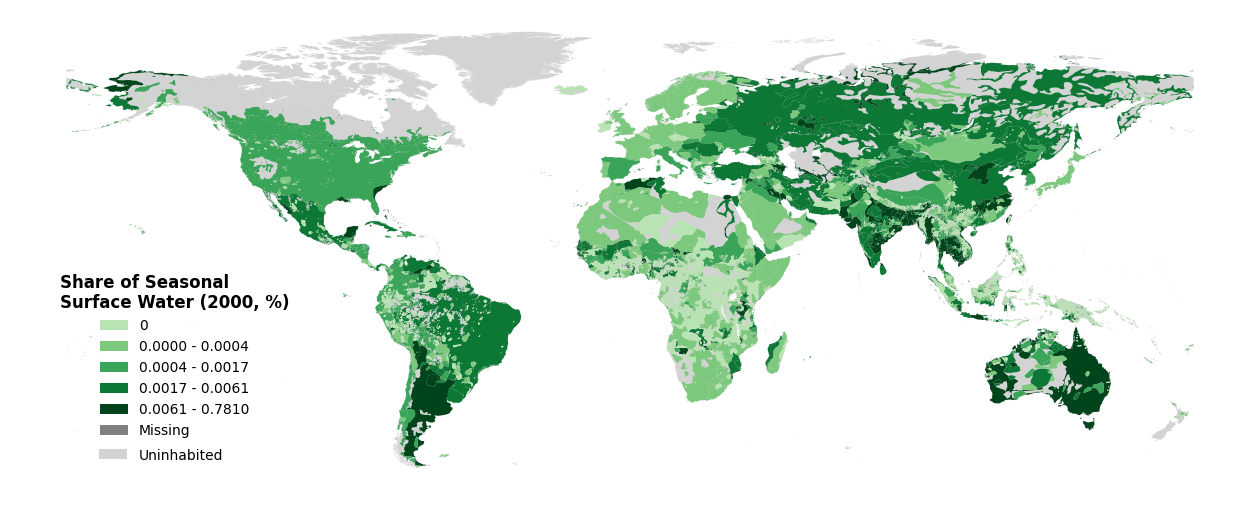

In [62]:
# Define the number of quantiles for the NON-ZERO values
num_quantiles = 4

# 82% of polygons have sh_seasonwater_base == 0, so a plain pd.qcut(q=5,
# duplicates="drop") would collapse to a single bin. Split zeros into their
# own "0%" category and run quintiles only on the non-zero subset.
poscol_shape['quantile_cat'] = pd.NA
mask_zero = poscol_shape['sh_seasonwater_base'] == 0
mask_nz   = poscol_shape['sh_seasonwater_base'] >  0

nz_cats, bins = pd.qcut(
    poscol_shape.loc[mask_nz, 'sh_seasonwater_base'], q=num_quantiles,
    retbins=True, labels=False, duplicates='drop'
)

poscol_shape.loc[mask_zero, 'quantile_cat'] = 0
poscol_shape.loc[mask_nz,   'quantile_cat'] = nz_cats + 1   # shift so 0 is reserved for zeros

# Creating the labels for the legend
label_map = {0: "0"}
for i in range(len(bins) - 1):
    label_map[i + 1] = f"{bins[i]:.4f} - {bins[i+1]:.4f}"

# Step 1: Extract unique categories (excluding NaNs)
categories = poscol_shape['quantile_cat'].dropna().unique()
categories = sorted(categories)

# Step 2: Sample colors from the same custom colormap as the other maps
# (one color per category — 6 total when zeros are present)
n = len(categories)
category_colors = strong_greens(np.linspace(0, 1, n))
category_color_map = dict(zip(categories, category_colors))

# Step 3: Map the colors to a new column
poscol_shape['color'] = poscol_shape['quantile_cat'].map(category_color_map)

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(16, 8), facecolor='white')

# Background
basemap_shape.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0
)

# Plot polygons with mapped colors
poscol_shape.plot(
    ax=ax,
    color=poscol_shape['color'].fillna('gray'),
    edgecolor='none',
    linewidth=0
)

# Custom legend
legend_elements = [
    Patch(facecolor=category_color_map[c], label=label_map.get(c, str(c)))
    for c in categories
]
legend_elements.append(Patch(facecolor='gray', label="Missing"))

# Show legend on the map
legend = ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.03, 0.1, 0.2, 0.2),
    frameon=False,
    title="Share of Seasonal\nSurface Water (2000, %)",
    title_fontproperties=FontProperties(weight='bold', size=12),
    prop=FontProperties(size=10)
)

# Uninhabited patch
uninhabited_patch = Patch(
    facecolor='lightgray',
    edgecolor='none',
    label='Uninhabited'
)
custom_legend = ax.legend(
    handles=[uninhabited_patch],
    loc='lower left',
    bbox_to_anchor=(0.062, 0.05, 0.2, 0.2),
    frameon=False,
    prop=FontProperties(size=10),
)
ax.add_artist(legend)

# Force same spatial extent
ax.set_aspect('equal', adjustable='box')
ax.set_axis_off()

# Save to PDF
plt.savefig(export_path / "ShSeasonwaterBase_POSCOL.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()
